# Spotify Popularity — Exploratory Data Analysis

**Dataset:** maharshipandya/spotify-tracks-dataset (~114 k raw rows)  
**Goal:** Predict whether a track is a *hit* (popularity ≥ 50) using audio features.  

This notebook follows the full EDA checklist required by the project rubric:
1. Dataset overview (shape, dtypes, missing values, duplicates, summary stats)
2. Feature distributions & outliers (histograms, skewness, boxplots)
3. Target distribution & class imbalance
4. Feature–target relationships (correlation heatmap, scatter plots)
5. Pairplot on a feature subset
6. Discrete & categorical feature counts

> **Notebook path note:** Run from the `notebooks/` directory.  
> `sys.path.insert(0, "..")` at the top adds the project root so `src` is importable.

## 0. Imports & Setup

In [1]:
# Add project root to sys.path so 'src' is importable when running from notebooks/
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules — load data the same way the pipeline does
from src import config
from src.data import load_raw, clean, add_label

# Consistent plot style across the notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

print("Imports OK")

Imports OK


---
## 1. Dataset Overview

We load the **raw** CSV first (before any cleaning) to inspect it as-delivered, then build the cleaned + labeled dataframe used throughout the rest of the notebook.

In [2]:
# --- Load raw data (no cleaning yet) ---
df_raw = load_raw()

print("=== Raw dataset shape ===")
print(f"  Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")

=== Raw dataset shape ===
  Rows: 114,000   Columns: 22


In [3]:
# First five rows — quick sanity check on column names and value ranges
df_raw.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Column names, dtypes, and non-null counts.
# This tells us which columns need type conversion and whether nulls exist.
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

### 1.1 Missing Values

A missing-value audit is the first thing to check after loading.  
Missing values can distort distributions and break models if not handled.

In [5]:
# Count missing values per column; show only columns that have at least one
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)

if missing_report.empty:
    print("No missing values found — dataset is complete.")
else:
    print(missing_report)

            missing_count  missing_pct
artists                 1          0.0
album_name              1          0.0
track_name              1          0.0


### 1.2 Duplicate Rows

The raw dataset contains duplicate `track_id` entries (the same song listed for multiple genres).  
We count them here to understand how many rows will be removed during cleaning.

In [6]:
# Count exact row duplicates, then also count duplicate track_ids specifically
exact_dups = df_raw.duplicated().sum()
trackid_dups = df_raw.duplicated(subset="track_id", keep="first").sum()

print(f"Exact duplicate rows : {exact_dups:,}")
print(f"Duplicate track_ids  : {trackid_dups:,}  ({trackid_dups/len(df_raw)*100:.1f}% of raw rows)")
print(f"Unique tracks        : {df_raw['track_id'].nunique():,}")

Exact duplicate rows : 0
Duplicate track_ids  : 24,259  (21.3% of raw rows)
Unique tracks        : 89,741


### 1.3 Build Cleaned + Labeled DataFrame

`clean()` drops duplicate `track_id`s, removes irrelevant identifier columns, and ensures correct dtypes.  
`add_label()` creates the binary `hit` column: 1 if popularity ≥ 50, else 0.

In [7]:
# Build the labeled dataframe used for all subsequent analysis
df = add_label(clean(df_raw))

print(f"Cleaned shape: {df.shape}  ({len(df_raw) - len(df):,} rows removed)")
print(f"Columns: {list(df.columns)}")

Cleaned shape: (89741, 17)  (24,259 rows removed)
Columns: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'hit']


### 1.4 Summary Statistics

`.describe()` gives us mean, median (50%), standard deviation, min, and max for every numeric column.  
This is the quickest way to spot scale differences (e.g., `duration_ms` vs `danceability`) and extreme ranges.

In [8]:
# Summary statistics for all numeric features + target
# Transpose so features are rows — easier to read with many columns
stats = df[config.NUMERIC_FEATURES + [config.TARGET]].describe().T
stats["median"] = df[config.NUMERIC_FEATURES + [config.TARGET]].median()
stats = stats[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
stats.round(3)

,count,mean,median,std,min,25%,75%,max
duration_ms,89741.0,229141.812,213293.000,112947.741,0.000,173040.000,264293.000,5237295.000
danceability,89741.0,0.562,0.576,0.177,0.000,0.450,0.692,0.985
energy,89741.0,0.634,0.676,0.257,0.000,0.457,0.853,1.000
loudness,89741.0,-8.499,-7.185,5.221,-49.531,-10.322,-5.108,4.532
speechiness,89741.0,0.087,0.049,0.113,0.000,0.036,0.086,0.965
acousticness,89741.0,0.328,0.188,0.338,0.000,0.017,0.625,0.996
instrumentalness,89741.0,0.173,0.000,0.324,0.000,0.000,0.098,1.000
liveness,89741.0,0.217,0.132,0.195,0.000,0.098,0.279,1.000
valence,89741.0,0.469,0.457,0.263,0.000,0.249,0.682,0.995
tempo,89741.0,122.058,122.013,30.118,0.000,99.264,140.077,243.372


---
## 2. Feature Distributions

Understanding how each feature is distributed helps us decide on preprocessing steps like scaling or log-transformation.  
Highly skewed features may mislead linear models if left untreated.

### 2.1 Histograms of Continuous Features

Each bar represents a bin of values. A tall bar means many tracks fall in that range.  
We plot all 10 continuous features in a grid so we can compare shapes at a glance.

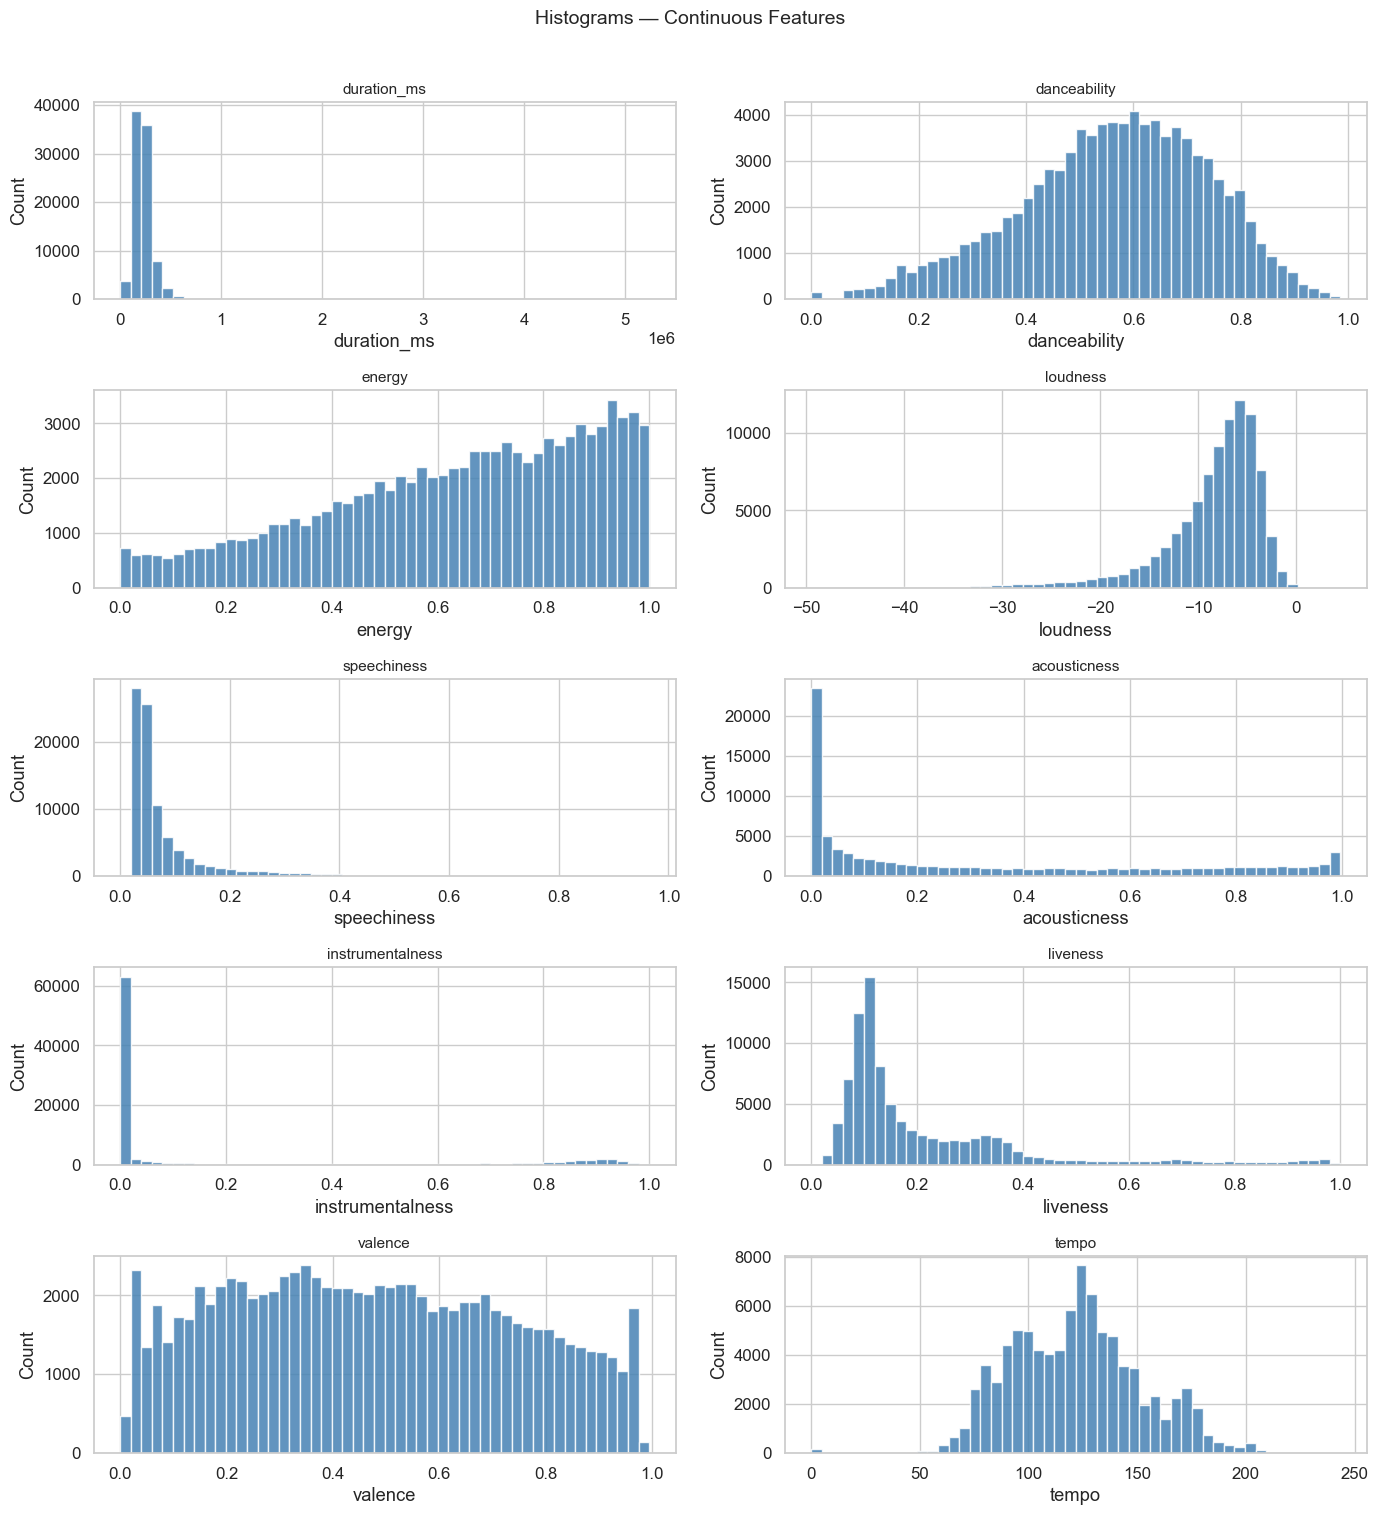

In [9]:
# Histograms for all continuous features — 2 columns × 5 rows grid
n_cont = len(config.CONTINUOUS_FEATURES)
n_cols = 2
n_rows = (n_cont + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(config.CONTINUOUS_FEATURES):
    axes[i].hist(df[feat].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Count")

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Histograms — Continuous Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Skewness

Skewness measures asymmetry in a distribution.  
- **|skew| > 1** → highly skewed (tail pulls the mean away from the median).  
- **|skew| > 0.5** → moderately skewed.  
- Features like `speechiness`, `instrumentalness`, and `liveness` tend to be right-skewed because most songs have low values but a few have very high ones.

Skewness of continuous features:
                   skewness      flag
duration_ms       11.072075      HIGH
speechiness        4.545863      HIGH
liveness           2.062106      HIGH
instrumentalness   1.564014      HIGH
acousticness       0.655741  MODERATE
tempo              0.182728       low
valence            0.127614       low
danceability      -0.398282       low
energy            -0.559989  MODERATE
loudness          -1.959883      HIGH


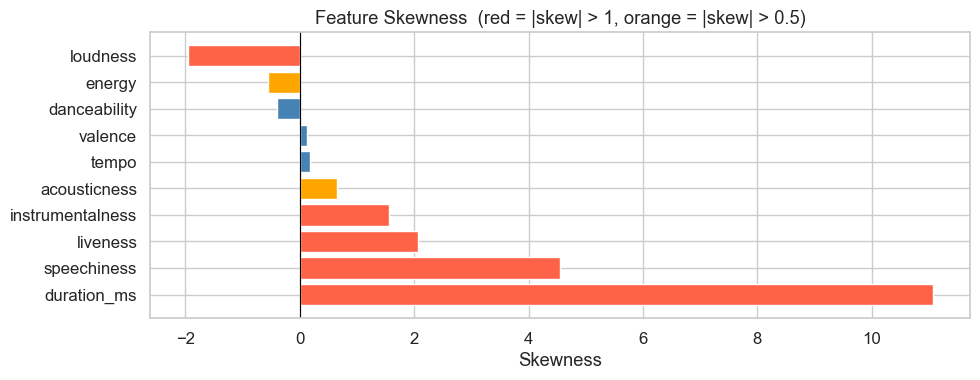

In [10]:
# Compute skewness for all continuous features; flag highly skewed ones
skew_vals = df[config.CONTINUOUS_FEATURES].skew().sort_values(ascending=False)
skew_df = skew_vals.rename("skewness").to_frame()
skew_df["flag"] = skew_df["skewness"].abs().apply(
    lambda x: "HIGH" if x > 1 else ("MODERATE" if x > 0.5 else "low")
)

print("Skewness of continuous features:")
print(skew_df.to_string())

# Bar chart of skewness values for visual comparison
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tomato" if abs(v) > 1 else ("orange" if abs(v) > 0.5 else "steelblue")
          for v in skew_vals]
ax.barh(skew_vals.index, skew_vals.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Skewness")
ax.set_title("Feature Skewness  (red = |skew| > 1, orange = |skew| > 0.5)")
plt.tight_layout()
plt.show()

### 2.3 Boxplots — Outlier Detection

A boxplot shows the median (center line), interquartile range (box), and whiskers (1.5× IQR).  
Points beyond the whiskers are **outliers**. Features with many outlier dots need attention — the pipeline applies IQR winsorization to continuous features.

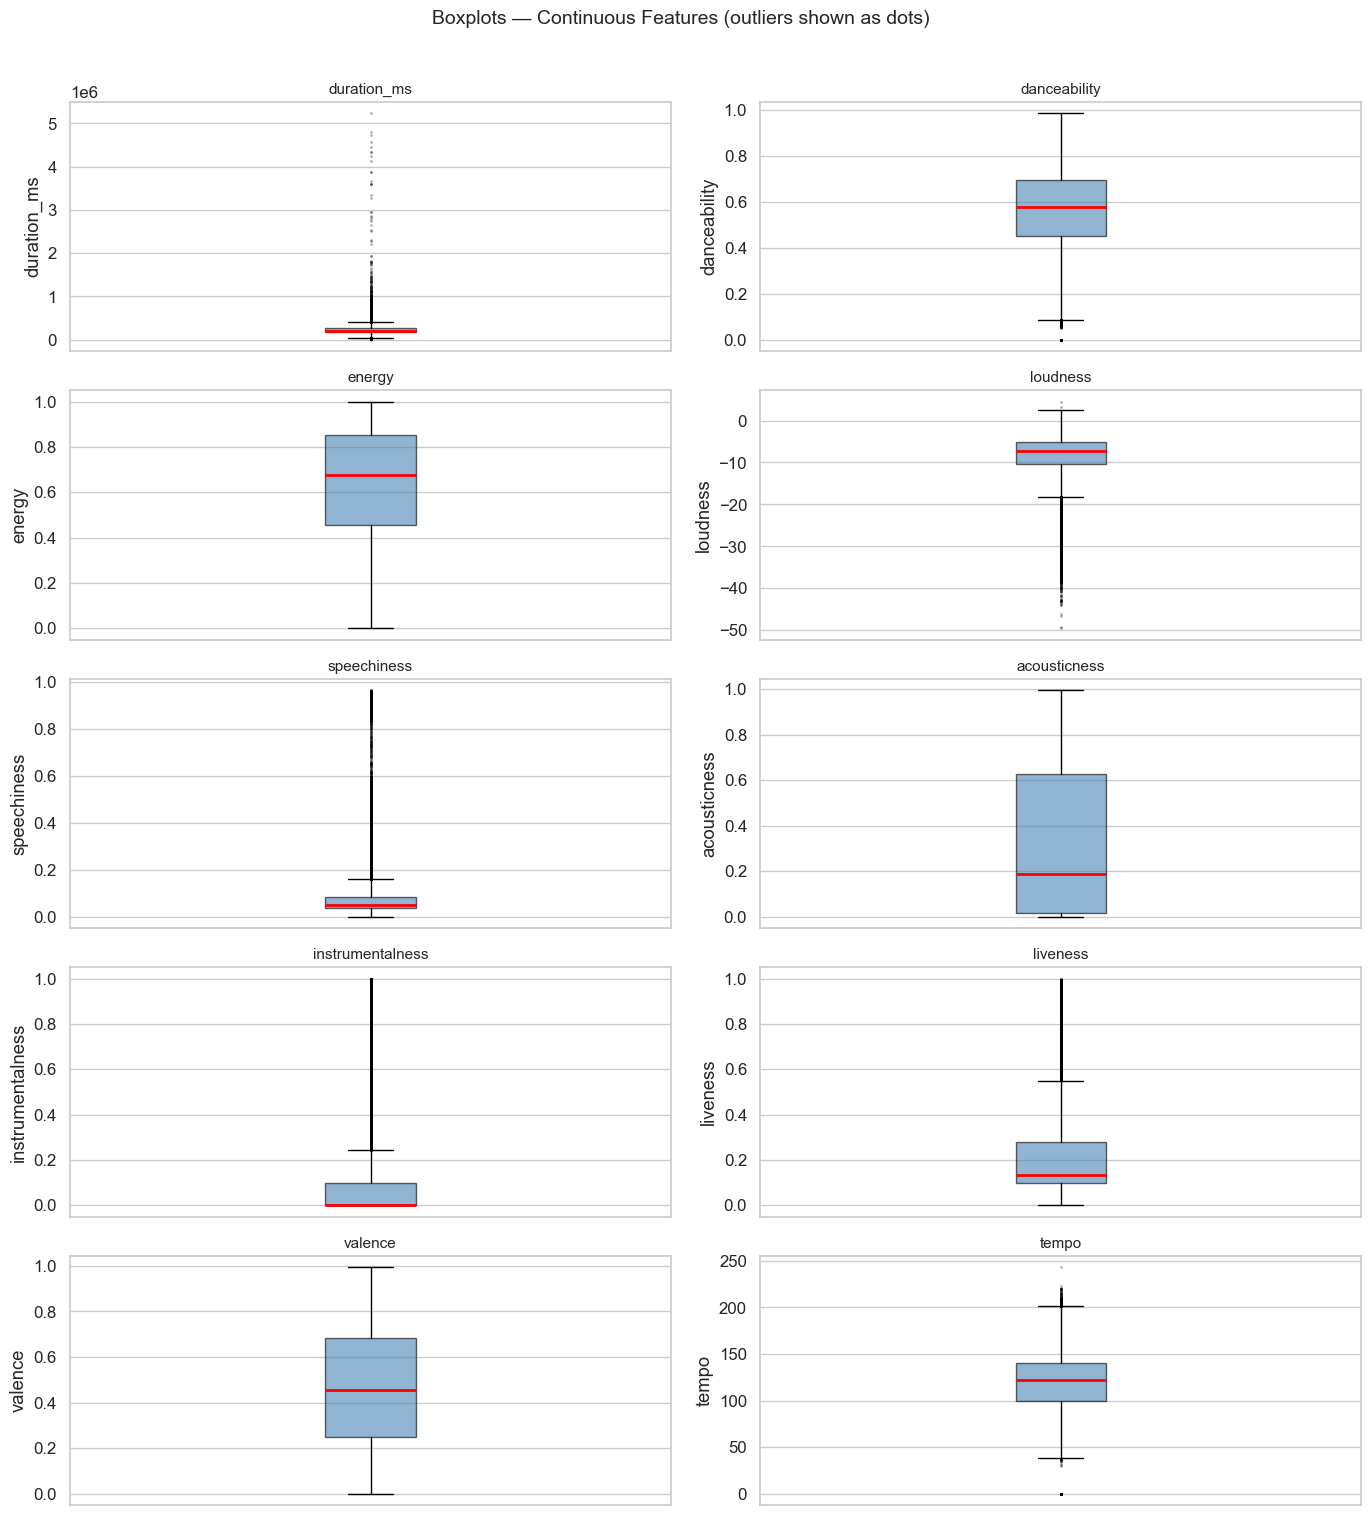

In [11]:
# Boxplots for all continuous features — same 2-column grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(config.CONTINUOUS_FEATURES):
    axes[i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_ylabel(feat)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots — Continuous Features (outliers shown as dots)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Target Variable — Popularity & Class Imbalance

Our target is `popularity` (0–100, continuous).  
We binarize it into `hit` (1 = popular, 0 = flop) using a threshold of **50**.  
Understanding the distribution and class balance is critical before modeling.

### 3.1 Popularity Distribution

Mean popularity  : 33.20
Median popularity: 33.00
Std dev          : 20.58


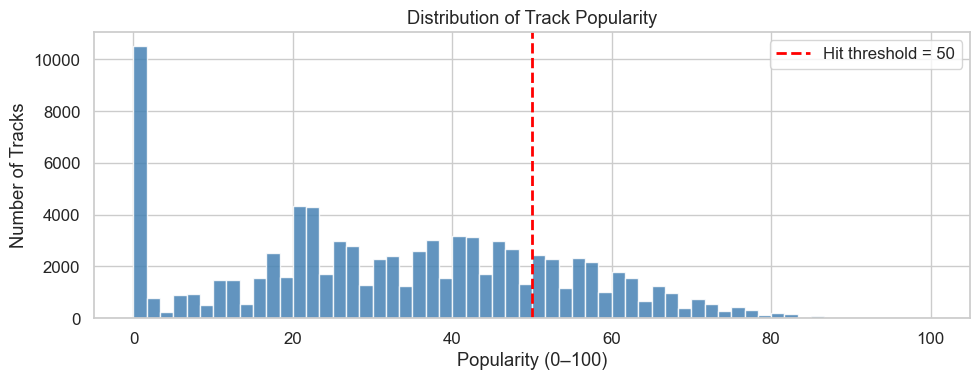

In [12]:
# Distribution of the raw popularity score (0–100)
# The vertical red line marks the hit/flop threshold
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df[config.TARGET], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(config.HIT_THRESHOLD, color="red", linewidth=2, linestyle="--",
           label=f"Hit threshold = {config.HIT_THRESHOLD}")
ax.set_xlabel("Popularity (0–100)")
ax.set_ylabel("Number of Tracks")
ax.set_title("Distribution of Track Popularity")
ax.legend()

print(f"Mean popularity  : {df[config.TARGET].mean():.2f}")
print(f"Median popularity: {df[config.TARGET].median():.2f}")
print(f"Std dev          : {df[config.TARGET].std():.2f}")

plt.tight_layout()
plt.show()

### 3.2 Class Imbalance — Hit vs Flop

If one class (flop) greatly outnumbers the other (hit), a naive model can reach high accuracy  
by always predicting the majority class — and still be useless.  
This is why we use **SMOTE** oversampling and look at precision/recall in addition to accuracy.

Class distribution:
  Flop (0): 68,532  (76.4%)
  Hit (1): 21,209  (23.6%)

Hit rate (% of tracks that are hits): 23.6%
Imbalance ratio (flop:hit)          : 3.23:1


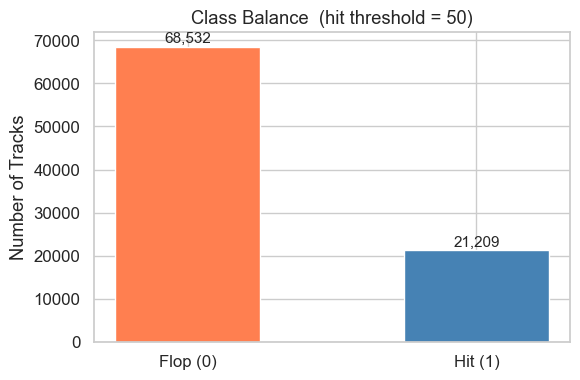

In [13]:
# Count hits vs flops and display the ratio
class_counts = df[config.LABEL].value_counts().sort_index()
class_labels = ["Flop (0)", "Hit (1)"]
hit_rate = df[config.LABEL].mean()

print("Class distribution:")
for label, count in class_counts.items():
    name = "Hit" if label == 1 else "Flop"
    print(f"  {name} ({label}): {count:,}  ({count/len(df)*100:.1f}%)")
print(f"\nHit rate (% of tracks that are hits): {hit_rate*100:.1f}%")
print(f"Imbalance ratio (flop:hit)          : {class_counts[0]/class_counts[1]:.2f}:1")

# Bar chart of class counts
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_labels, class_counts.values,
              color=["coral", "steelblue"], edgecolor="white", width=0.5)

# Annotate each bar with its count
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{count:,}", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Number of Tracks")
ax.set_title(f"Class Balance  (hit threshold = {config.HIT_THRESHOLD})")
plt.tight_layout()
plt.show()

### Class Balance: Before vs After SMOTE

The raw training set is imbalanced — roughly **24% hits** vs 76% flops — which means a naive model can achieve high accuracy simply by always predicting "flop".
SMOTE (Synthetic Minority Over-sampling Technique) addresses this by synthesizing new minority (hit) samples: it picks a real hit, finds its nearest neighbors among other hits, and interpolates between them to create plausible synthetic tracks.
Crucially, SMOTE is applied **only to the training split** inside the modeling pipeline — the test set is never touched — so class-balance adjustment cannot leak future information.

Class counts BEFORE SMOTE (training split):
  Flop (0): 54,825
  Hit  (1): 16,967
  Ratio  : 3.23:1

Class counts AFTER SMOTE (training split):
  Flop (0): 54,825
  Hit  (1): 54,825
  Ratio  : 1.00:1


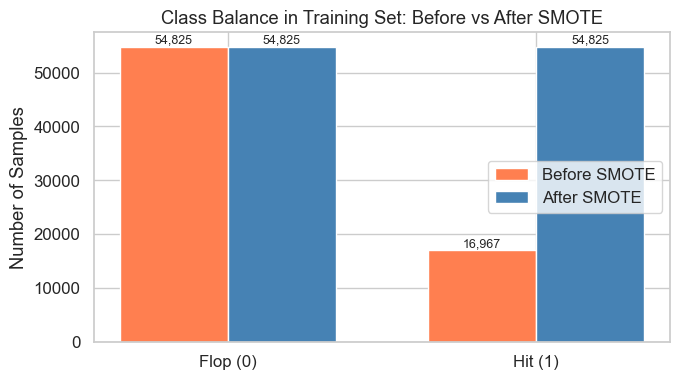

In [14]:
# ── Class Balance: Before vs After SMOTE ──────────────────────────────────────
# Import split and SMOTE (imbalanced-learn must be installed)
from src.data import split
from src.features import make_preprocessor
from imblearn.over_sampling import SMOTE

# 1. Split labeled df into train/test; we only need the training portion
X_train, X_test, y_train, y_test = split(df)

# 2. Capture BEFORE counts
before_counts = y_train.value_counts().sort_index()  # {0: flops, 1: hits}

# 3. Preprocess X_train (no scaling needed for SMOTE — tree models handle raw scale)
preprocessor = make_preprocessor(scale=False)
X_train_t = preprocessor.fit_transform(X_train)

# 4. Apply SMOTE on training data ONLY → balanced y_res
sm = SMOTE(random_state=config.RANDOM_STATE)
_, y_res = sm.fit_resample(X_train_t, y_train)

# 5. Capture AFTER counts
after_counts = y_res.value_counts().sort_index()  # {0: flops, 1: hits}

# ── Print counts ──────────────────────────────────────────────────────────────
print("Class counts BEFORE SMOTE (training split):")
print(f"  Flop (0): {before_counts[0]:,}")
print(f"  Hit  (1): {before_counts[1]:,}")
print(f"  Ratio  : {before_counts[0]/before_counts[1]:.2f}:1")
print()
print("Class counts AFTER SMOTE (training split):")
print(f"  Flop (0): {after_counts[0]:,}")
print(f"  Hit  (1): {after_counts[1]:,}")
print(f"  Ratio  : {after_counts[0]/after_counts[1]:.2f}:1")

# ── Grouped bar chart ─────────────────────────────────────────────────────────
import numpy as np

labels  = ["Flop (0)", "Hit (1)"]
before_vals = [before_counts[0], before_counts[1]]
after_vals  = [after_counts[0],  after_counts[1]]

x     = np.arange(len(labels))  # label positions
width = 0.35                     # bar width

fig, ax = plt.subplots(figsize=(7, 4))
bars_before = ax.bar(x - width / 2, before_vals, width,
                     label="Before SMOTE", color="coral",      edgecolor="white")
bars_after  = ax.bar(x + width / 2, after_vals,  width,
                     label="After SMOTE",  color="steelblue",  edgecolor="white")

# Annotate bars with count labels
for bar in list(bars_before) + list(bars_after):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 200,
        f"{int(height):,}", ha="center", va="bottom", fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Number of Samples")
ax.set_title("Class Balance in Training Set: Before vs After SMOTE")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Feature–Target Relationships

We now explore how individual features relate to the target (`popularity`).  
This guides feature selection and helps explain model predictions.

### 4.1 Correlation Heatmap

Pearson correlation ranges from -1 (perfect negative) to +1 (perfect positive).  
The heatmap shows correlations between **all pairs** of numeric features.  
Pairs near ±1 indicate redundancy; pairs near 0 are linearly independent.

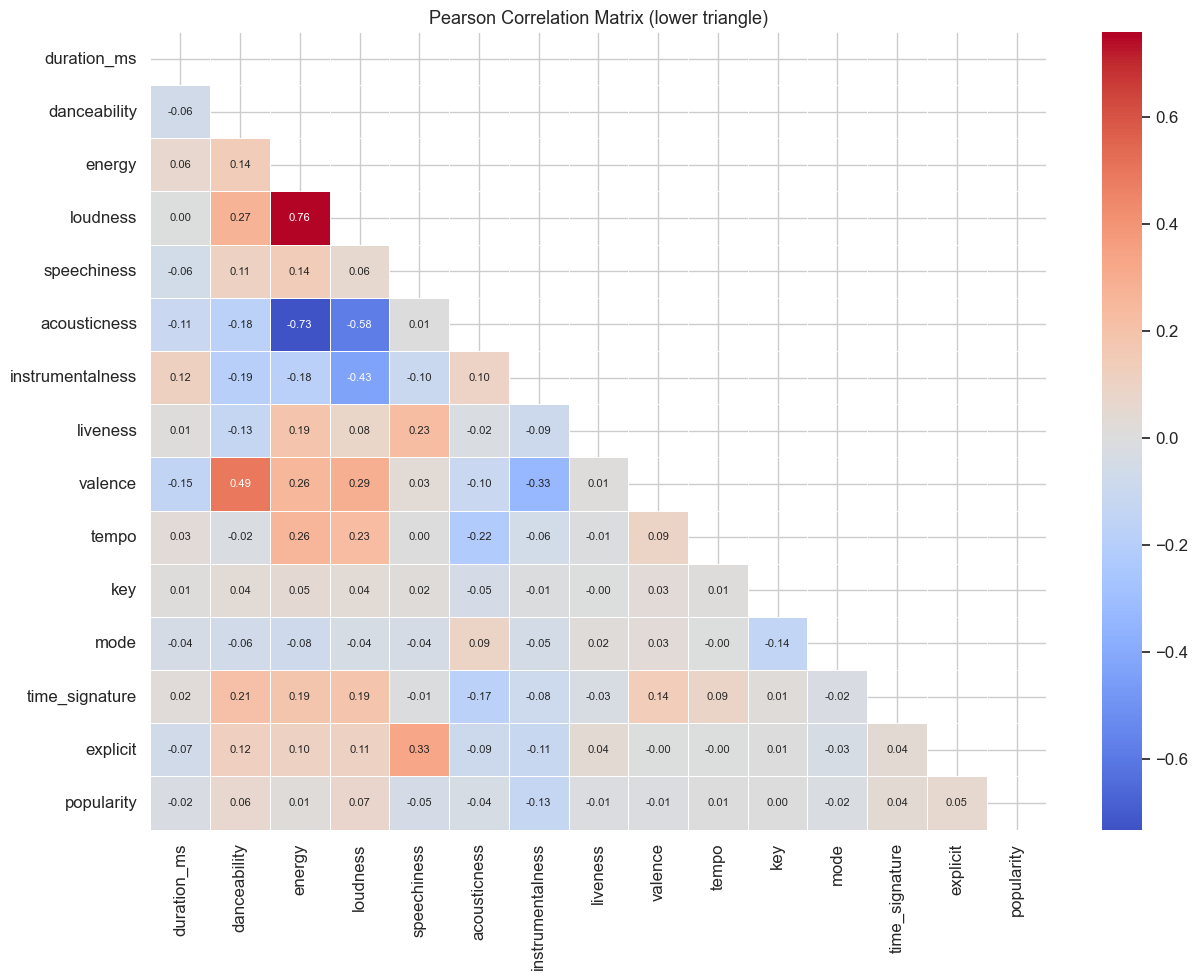

In [15]:
# Full correlation matrix including the target
corr_cols = config.NUMERIC_FEATURES + [config.TARGET]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Pearson Correlation Matrix (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Per-Feature Correlation with Popularity

A sorted bar chart of each feature's correlation with `popularity` makes it easy to see which features have the strongest (positive or negative) linear relationship with the target.

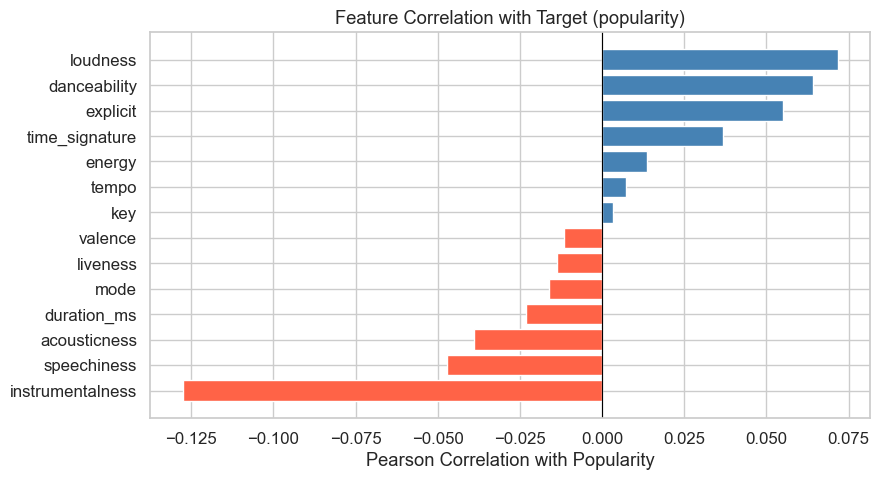

instrumentalness   -0.127465
speechiness        -0.047081
acousticness       -0.038847
duration_ms        -0.023119
mode               -0.016214
liveness           -0.013844
valence            -0.011526
key                 0.003432
tempo               0.007270
energy              0.013728
time_signature      0.036893
explicit            0.054902
danceability        0.064281
loudness            0.071676
dtype: float64


In [16]:
# Correlation of each numeric feature with the popularity target
target_corr = df[config.NUMERIC_FEATURES].corrwith(df[config.TARGET]).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tomato" if v < 0 else "steelblue" for v in target_corr]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Popularity")
ax.set_title("Feature Correlation with Target (popularity)")
plt.tight_layout()
plt.show()

print(target_corr)

### 4.3 Scatter Plots — Key Features vs Popularity

Scatter plots reveal whether a feature's relationship with popularity is linear, curved, or noisy.  
We select the three features with the highest absolute correlation: `loudness`, `danceability`, and `instrumentalness` (strong negative).

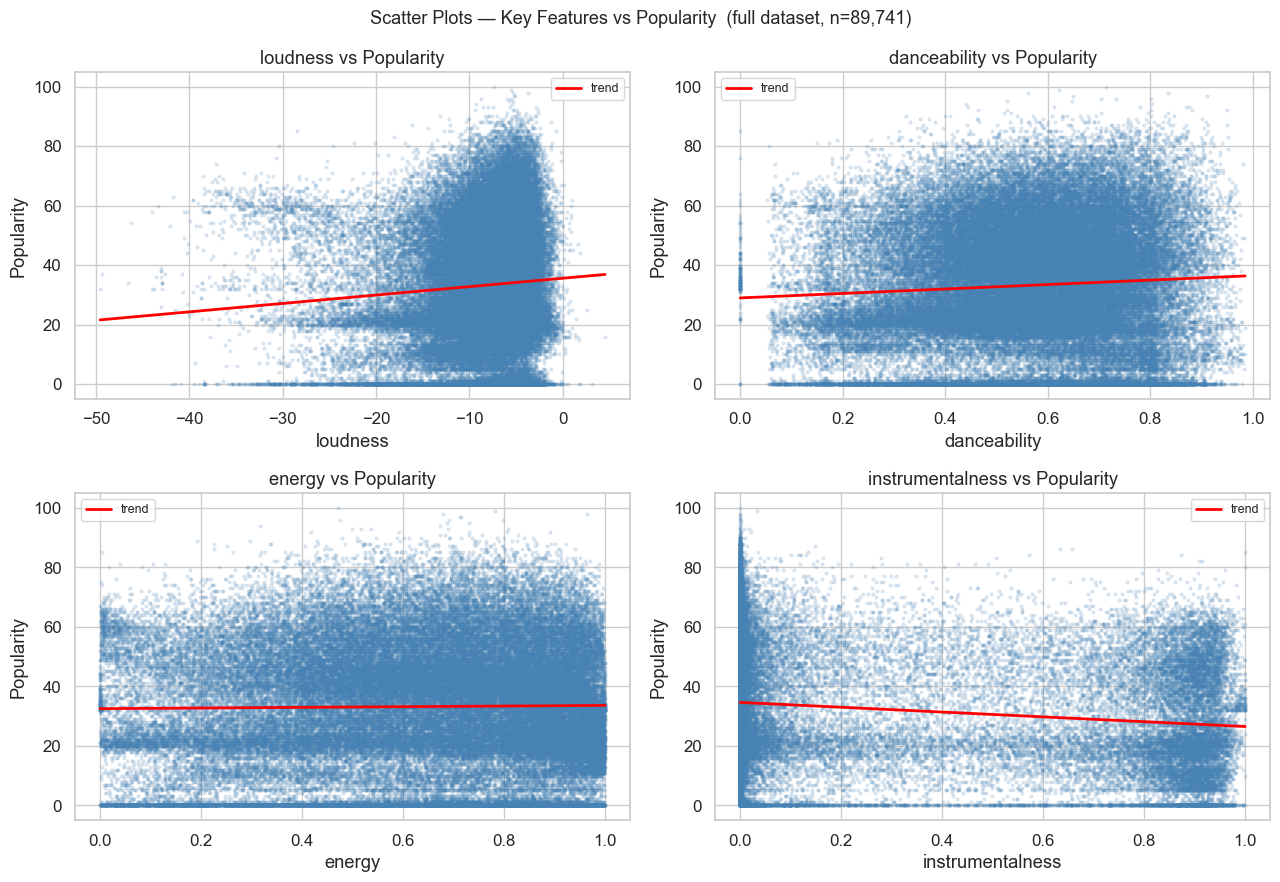

In [17]:
# Key features to scatter-plot against popularity
# Chosen by highest |correlation| from the bar chart above
SCATTER_FEATURES = ["loudness", "danceability", "energy", "instrumentalness"]

# Plot the FULL cleaned dataframe (~89,741 rows).
# rasterized=True converts the dense point cloud to a bitmap layer so the
# saved figure stays small; small s and low alpha keep overplotting readable.

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(SCATTER_FEATURES):
    axes[i].scatter(
        df[feat], df[config.TARGET],
        alpha=0.15, s=4, color="steelblue", rasterized=True
    )
    # Add a linear regression trend line using numpy polyfit
    x_vals = df[feat].values
    y_vals = df[config.TARGET].values
    mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
    m, b = np.polyfit(x_vals[mask], y_vals[mask], 1)
    x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="red", linewidth=2, label="trend")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Popularity")
    axes[i].set_title(f"{feat} vs Popularity")
    axes[i].legend(fontsize=9)

fig.suptitle(
    f"Scatter Plots — Key Features vs Popularity  (full dataset, n={len(df):,})",
    fontsize=13
)
plt.tight_layout()
plt.show()

### 4.4 Pairplot — Feature Subset

A pairplot shows every pairwise scatter plot plus a diagonal histogram, color-coded by class.  
This is the most comprehensive overview of feature interactions in one figure.

> **Performance note:** This cell uses the **full cleaned dataset** (~89,741 rows) for accuracy.  
> Rendering takes approximately 30–40 seconds — that is expected for an offline notebook.

Pairplot on full dataset: 89,741 rows × 5 features


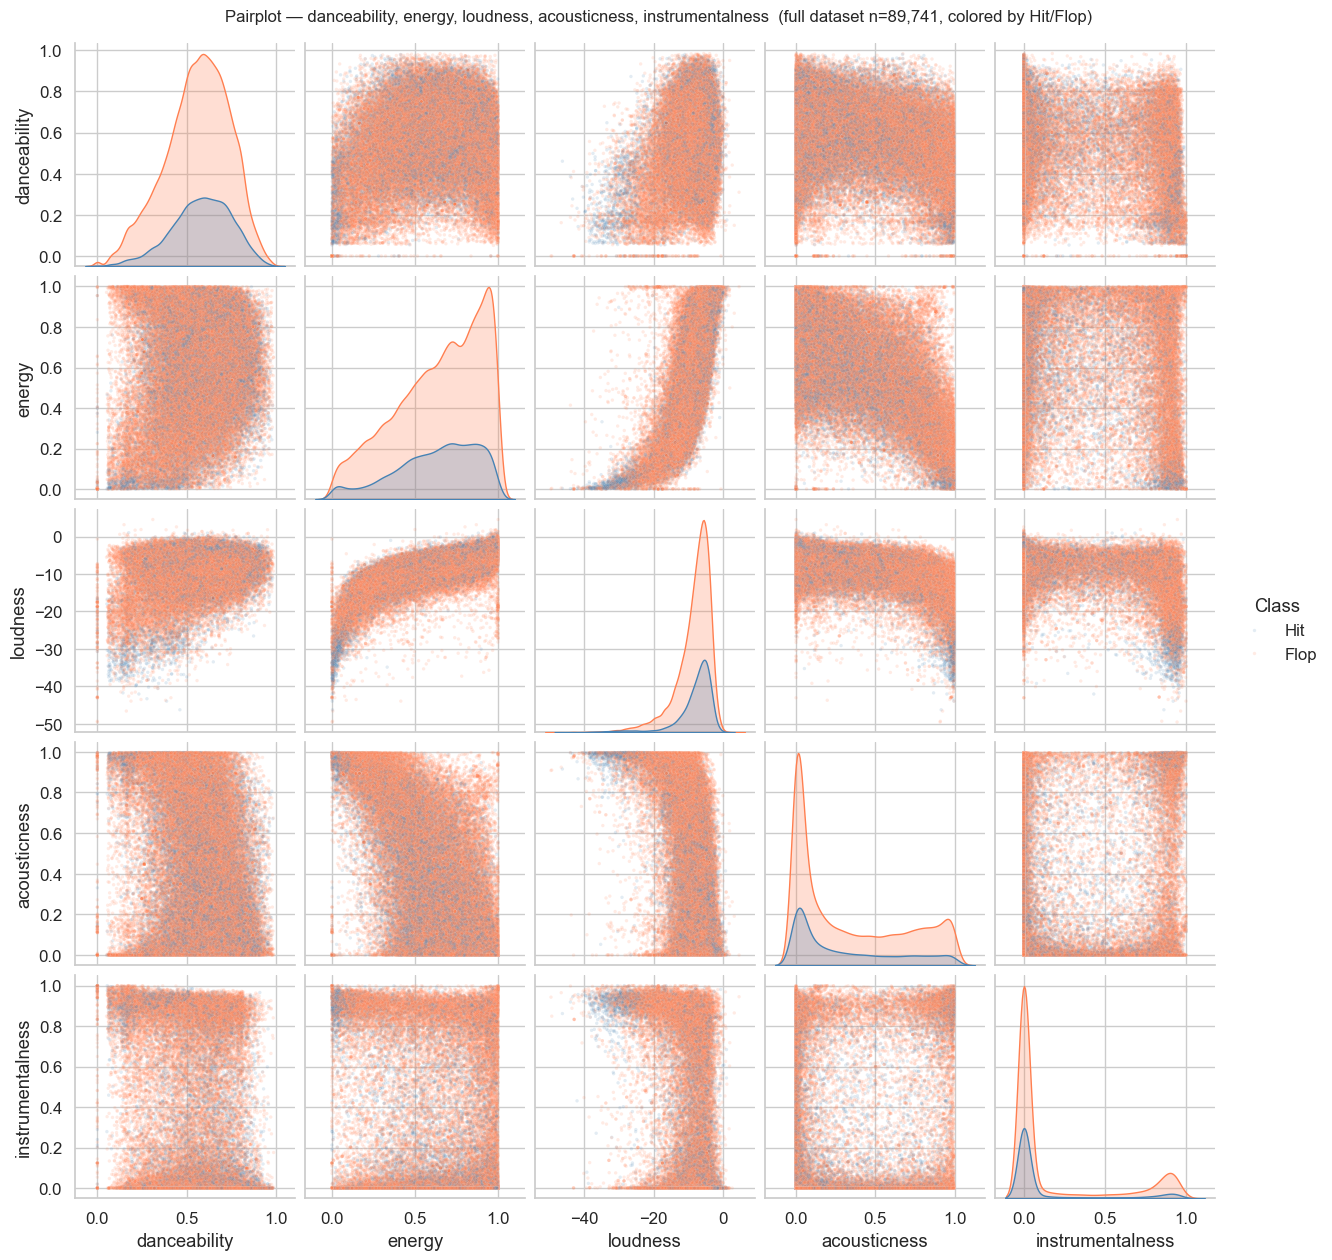

In [18]:
# Subset of most informative features for pairplot
PAIRPLOT_FEATURES = ["danceability", "energy", "loudness", "acousticness", "instrumentalness"]

# Build the pairplot on the FULL cleaned dataframe (no sampling).
# rasterized=True keeps the PDF/SVG output size manageable; small s and
# low alpha reduce overplotting on ~89 k points.
df_pair = df[PAIRPLOT_FEATURES + [config.LABEL]].copy()

# Label the binary column with readable names for the legend
df_pair["Class"] = df_pair[config.LABEL].map({0: "Flop", 1: "Hit"})

print(f"Pairplot on full dataset: {len(df_pair):,} rows × {len(PAIRPLOT_FEATURES)} features")

g = sns.pairplot(
    df_pair,
    hue="Class",
    vars=PAIRPLOT_FEATURES,
    palette={"Flop": "coral", "Hit": "steelblue"},
    plot_kws={"alpha": 0.15, "s": 6, "rasterized": True},
    diag_kind="kde",
)
g.fig.suptitle(
    f"Pairplot — {', '.join(PAIRPLOT_FEATURES)}  (full dataset n={len(df_pair):,}, colored by Hit/Flop)",
    y=1.01, fontsize=12
)
plt.show()

---
## 5. Discrete & Categorical Features

Discrete features like `key`, `mode`, `time_signature`, and `explicit` are integers representing categories.  
Countplots show how tracks are distributed across each category — and whether popularity differs by category.

### 5.1 Countplots — Discrete Features

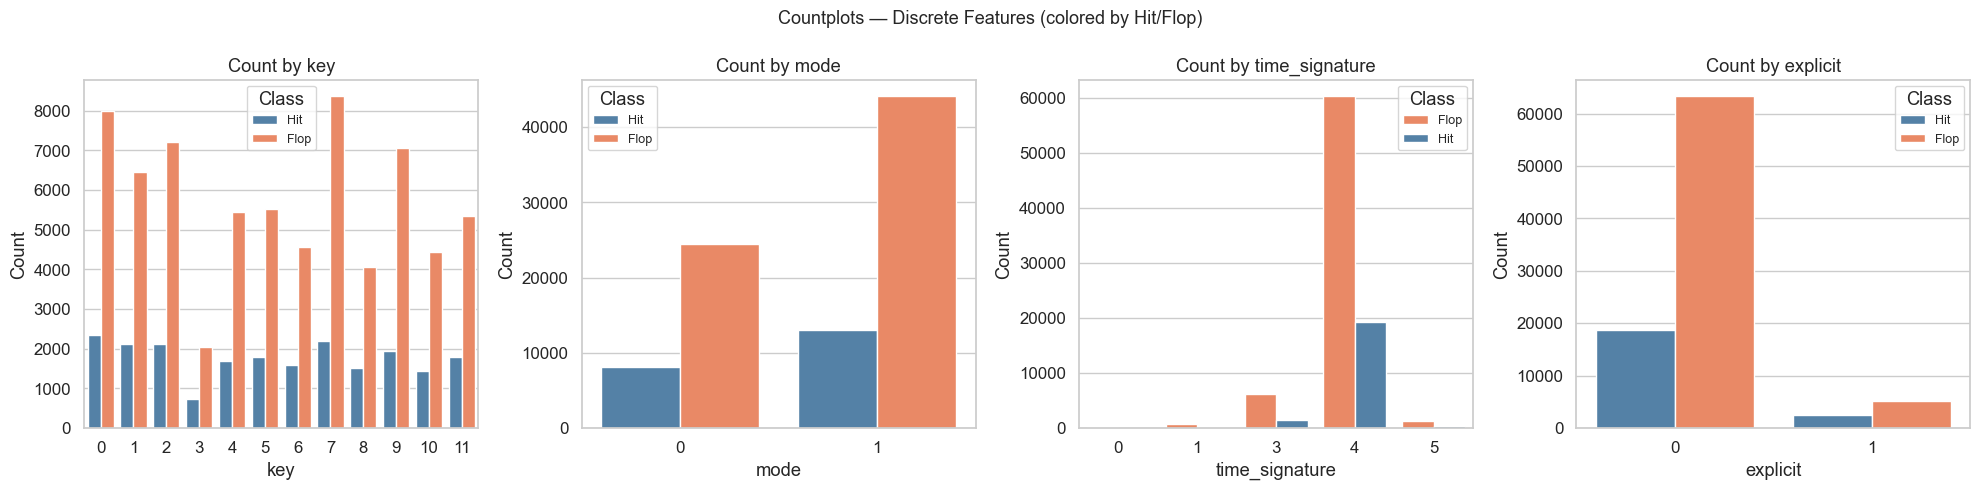

In [19]:
# Countplots for discrete features, colored by hit/flop to reveal class patterns
# e.g., are explicit tracks more often hits?
n_disc = len(config.DISCRETE_FEATURES)
fig, axes = plt.subplots(1, n_disc, figsize=(5 * n_disc, 5))

# Map binary label to readable string for legend
df["Class"] = df[config.LABEL].map({0: "Flop", 1: "Hit"})

for i, feat in enumerate(config.DISCRETE_FEATURES):
    sns.countplot(
        data=df,
        x=feat,
        hue="Class",
        palette={"Flop": "coral", "Hit": "steelblue"},
        ax=axes[i],
        order=sorted(df[feat].unique()),
    )
    axes[i].set_title(f"Count by {feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Class", fontsize=9)

fig.suptitle("Countplots — Discrete Features (colored by Hit/Flop)", fontsize=13)
plt.tight_layout()
plt.show()

# Clean up helper column
df.drop(columns=["Class"], inplace=True)

### 5.2 Top Track Genres by Count

`track_genre` is a high-cardinality categorical feature (many unique values).  
We plot the **top 20 genres by track count**, then look at which genres have the highest average popularity.

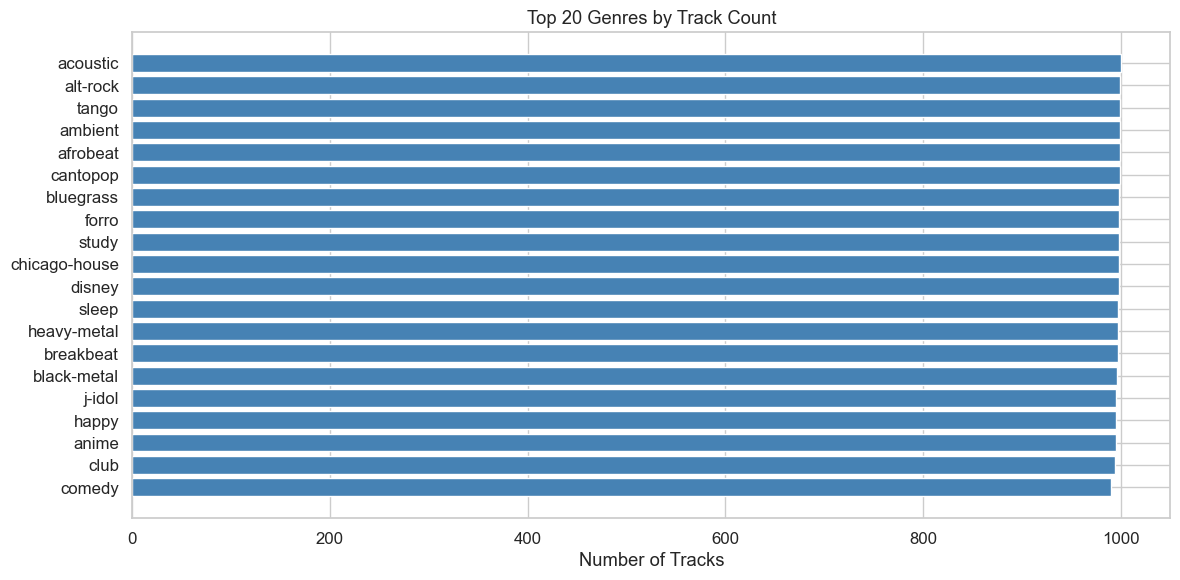

Total unique genres: 113


In [20]:
# Top 20 genres by number of tracks
TOP_N_GENRES = 20
top_genres = df["track_genre"].value_counts().head(TOP_N_GENRES)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_genres.index[::-1], top_genres.values[::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Tracks")
ax.set_title(f"Top {TOP_N_GENRES} Genres by Track Count")
plt.tight_layout()
plt.show()

print(f"Total unique genres: {df['track_genre'].nunique()}")

### 5.3 Top Genres by Mean Popularity

Some genres are more popular on average than others. This plot shows the 15 genres with the highest mean popularity score — useful context for the model and for interpreting genre-based predictions.

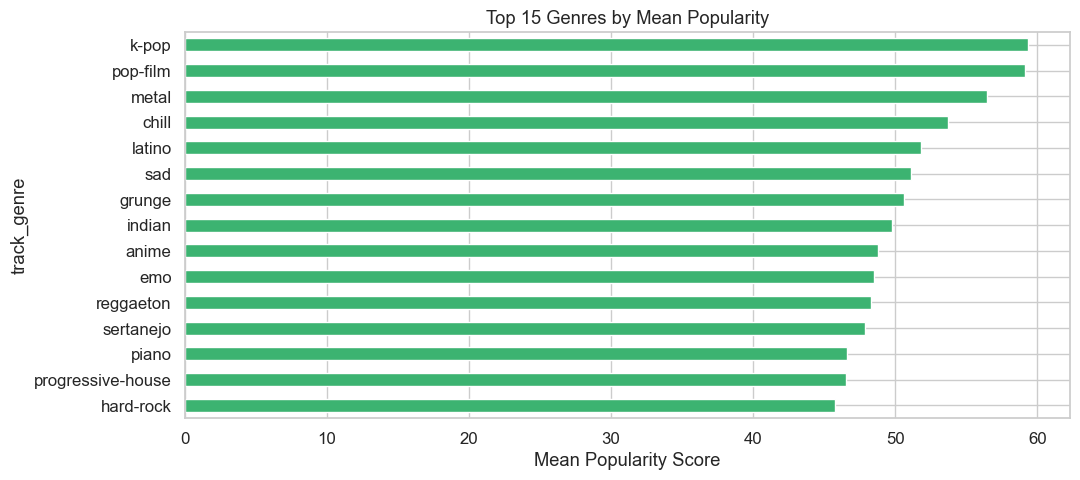

In [21]:
# Mean popularity per genre — top 15 most popular genres on average
TOP_N_POP = 15
genre_pop = (
    df.groupby("track_genre")[config.TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N_POP)
)

fig, ax = plt.subplots(figsize=(11, 5))
genre_pop[::-1].plot(kind="barh", ax=ax, color="mediumseagreen", edgecolor="white")
ax.set_xlabel("Mean Popularity Score")
ax.set_title(f"Top {TOP_N_POP} Genres by Mean Popularity")
plt.tight_layout()
plt.show()

### 5.4 Hit Rate by Genre (Top 20)

Hit rate = fraction of tracks in a genre that are hits.  
A genre with a high hit rate means its tracks cluster above the popularity threshold more often.

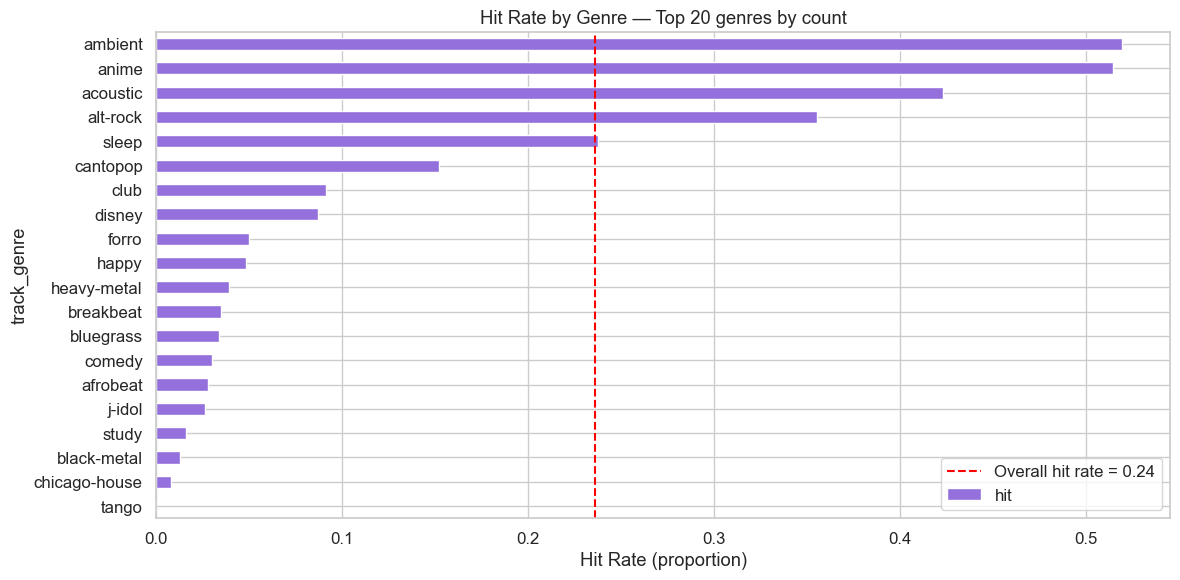

In [22]:
# Hit rate per genre for the top-20 genres by track count
top_genre_names = df["track_genre"].value_counts().head(TOP_N_GENRES).index
genre_hitrate = (
    df[df["track_genre"].isin(top_genre_names)]
    .groupby("track_genre")[config.LABEL]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
genre_hitrate[::-1].plot(kind="barh", ax=ax, color="mediumpurple", edgecolor="white")
ax.axvline(df[config.LABEL].mean(), color="red", linestyle="--",
           label=f"Overall hit rate = {df[config.LABEL].mean():.2f}")
ax.set_xlabel("Hit Rate (proportion)")
ax.set_title(f"Hit Rate by Genre — Top {TOP_N_GENRES} genres by count")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. EDA Summary & Key Takeaways

Below we summarize the most important findings from the EDA, which motivate the preprocessing and modeling choices in later notebooks.

In [23]:
# Print a concise EDA summary
hit_count   = df[config.LABEL].sum()
flop_count  = (df[config.LABEL] == 0).sum()
hit_rate    = df[config.LABEL].mean()

high_skew   = df[config.CONTINUOUS_FEATURES].skew().abs()
high_skew   = high_skew[high_skew > 1].sort_values(ascending=False)

top_corr    = df[config.NUMERIC_FEATURES].corrwith(df[config.TARGET]).abs().sort_values(ascending=False)

print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"Cleaned dataset  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Raw rows removed : {len(df_raw) - len(df):,} (duplicates + nulls)")
print()
print("Target (popularity):")
print(f"  Mean: {df[config.TARGET].mean():.1f}   Median: {df[config.TARGET].median():.1f}")
print()
print("Class balance (hit = popularity >= 50):")
print(f"  Hits : {hit_count:,}  ({hit_rate*100:.1f}%)")
print(f"  Flops: {flop_count:,}  ({(1-hit_rate)*100:.1f}%)")
print(f"  → Dataset is imbalanced; SMOTE will be applied in preprocessing.")
print()
print("Highly skewed features (|skew| > 1):")
for feat, val in high_skew.items():
    print(f"  {feat:<20s} skew = {val:.2f}")
print(f"  → IQR winsorization applied to continuous features in pipeline.")
print()
print("Top 5 features correlated with popularity:")
for feat, val in top_corr.head(5).items():
    print(f"  {feat:<20s} |r| = {val:.3f}")
print()
print("Note: all correlations are low (|r| < 0.15), confirming this is a non-linear")
print("problem — tree-based ensemble models (Random Forest, XGBoost) are well-suited.")
print("=" * 55)

EDA SUMMARY
Cleaned dataset  : 89,741 rows × 17 columns
Raw rows removed : 24,259 (duplicates + nulls)

Target (popularity):
  Mean: 33.2   Median: 33.0

Class balance (hit = popularity >= 50):
  Hits : 21,209  (23.6%)
  Flops: 68,532  (76.4%)
  → Dataset is imbalanced; SMOTE will be applied in preprocessing.

Highly skewed features (|skew| > 1):
  duration_ms          skew = 11.07
  speechiness          skew = 4.55
  liveness             skew = 2.06
  loudness             skew = 1.96
  instrumentalness     skew = 1.56
  → IQR winsorization applied to continuous features in pipeline.

Top 5 features correlated with popularity:
  instrumentalness     |r| = 0.127
  loudness             |r| = 0.072
  danceability         |r| = 0.064
  explicit             |r| = 0.055
  speechiness          |r| = 0.047

Note: all correlations are low (|r| < 0.15), confirming this is a non-linear
problem — tree-based ensemble models (Random Forest, XGBoost) are well-suited.
